In [1]:
import joblib
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
)


In [2]:
X_train = joblib.load('X_train_cat.pkl')
X_val   = joblib.load('X_val_cat.pkl')


y_train = joblib.load('y_train.pkl')
y_val   = joblib.load('y_val.pkl')

In [3]:
cat_cols = [
'department',
'role',
'shift',
'age_group'
]


In [4]:
cb = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    auto_class_weights='Balanced',
    loss_function='Logloss',
    random_state=42,
    verbose=0
)

cb.fit( X_train, y_train, cat_features=cat_cols)

CatBoostClassifier(auto_class_weights='Balanced', depth=6, iterations=300, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=0)

In [5]:
y_prob = cb.predict_proba(X_val)[:,1]

threshold = 0.40

y_pred = (y_prob >= threshold).astype(int)

In [6]:
print(classification_report(y_val,y_pred))
print("ROC AUC:", roc_auc_score(y_val,y_prob))

              precision    recall  f1-score   support

           0       0.86      0.51      0.64      1120
           1       0.34      0.76      0.47       380

    accuracy                           0.57      1500
   macro avg       0.60      0.63      0.56      1500
weighted avg       0.73      0.57      0.60      1500

ROC AUC: 0.6886912593984963


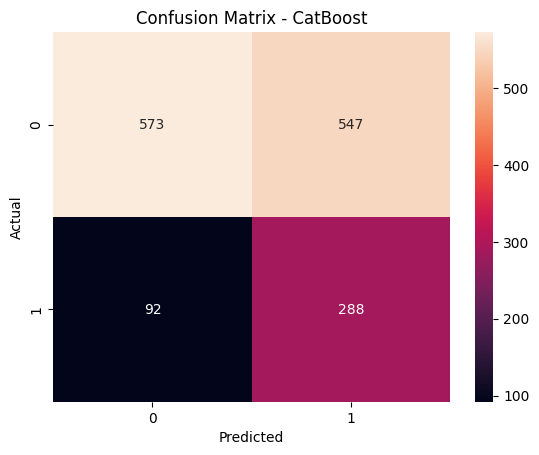

In [7]:
cm = confusion_matrix(y_val,y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - CatBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
joblib.dump(cb,'catboost_model.pkl')

['catboost_model.pkl']